# GPR Placed Above a Homogeneous Earth

In this notebook we take a look at `elfe3D_GPR`'s solution to a two-media model: air and a homogeneous earth. Its solution is compared by a semi-analytical reference solution. ()

## 1. Imports, Path and Platform Configuration

These imports to the I/O module, the path and platform configurations are similar to the first example.

In [ ]:
import os
from pathlib import Path

# inputs
from elfe3d_gpr_io.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.postprocess import field_error, error_stats
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)

MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = "",
    use_wsl    = True,          # False if running the notebook from native Linux.
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


## 2: Generating the Geophysical Model

We will use the same geometrical model as the first example notebook, except change the dielectric parameters of the material below the origin of the model.

This material is set to have a relative electric permittivity $\varepsilon_r$ of $4$, electrical conductivity $\sigma$ of $1e\text{-}4$ S/m, and is non-magnetic.

In [2]:
f    = 100e6        # Single Frequency Simulation
wave = 3e8 / f

survey = GPRSurvey.build(
    experiment_name = 'homogeneous_earth',
    base_dir        = MASTER_PATH,

    # Domain
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Material definition (air/free-space)
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    # Material definition (earth layer)
    layer_thicknesses = [wave/10],
    layer_eps_r       = [4.0],
    layer_sigma       = [1e-4], 
    layer_mu_r        = [1.0],
    layer_sigma_m     = [0.0],

    # Source
    f_list              = [f],
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 20, 
)

survey.generate()
print('poly :', survey.io.poly_file)


odepths: [np.float64(0.0375), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Input generation complete.
poly : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_homogeneous_earth.poly


It should be noted that the `least_samples_per_wavelength` variable has a lower value of $20$ in this simulation than in the first example ($40$). That is because it is found to be a sufficient discretization level in terms of accuracy vs the semi-analytical solution of homogeneous earth.

## 3. Mesh generation with `tetgen`

We generate the mesh based on the inputs - same as before.

In [3]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_homogeneous_earth.poly.
Delaunizing vertices...
Delaunay seconds:  0.002343
Creating surface mesh ...
Surface mesh seconds:  0.001106
Constrained Delaunay...
Constrained Delaunay seconds:  0.002056
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000206
Refining mesh...
Refinement seconds:  1.26472
Optimizing mesh...
Optimization seconds:  0.060434

Writing GPR_model_homogeneous_earth.1.node.
Writing GPR_model_homogeneous_earth.1.ele.
Writing GPR_model_homogeneous_earth.1.face.
Writing GPR_model_homogeneous_earth.1.edge.
Writing GPR_model_homogeneous_earth.1.vtk.
Writing GPR_model_homogeneous_earth.1.neigh.

Output seconds:  1.0769
Total running seconds:  2.40785

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 66155
  Mesh tetrahedra: 397603
  Mesh faces: 800491
  Mesh edges: 469042
  Mesh faces on facets: 46042
  Mesh edges on segments: 1900

## 4. Run the Fortran solver

We now have all simulation inputs ready. Hence, we can run the simulation now.

In [4]:
run_solver(paths,survey)

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_homogeneous_earth.                   
Your mesh has
       66155 Nodes
      397603 Elements
      469042 Edges (dof)
*************************************
Assembling connectivity arrays
Calculating interpolation coefficients
Obtaining model properties
*************************************
Source parameters:
 CSTYPE           6
 source-start coordinates:
  -1.4999999999999999E-004   0

## 5. Load solver results
Once the simulation is completed running, `elfe3d_gpr_io` can read the results.

In [5]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR homogeneous earth', # Changed label for plotting
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## 6. Load analytical reference solution for the homogeneous half-space model.

A semi-analytical solution for this model has been evaluated and stored in the data folder. This is now read by the `elfe3d_gpr_io`'s `AnalyticalLoader` class.

In [6]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

# Loading the analytical equivalent to the simulation.
semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_100MHz_NR.csv'),
    label='semi_analytical',
).endfire()

## 7. Compare computed field to analytical reference

### 7.1. Plotting the base receiver-line data against analytical solution

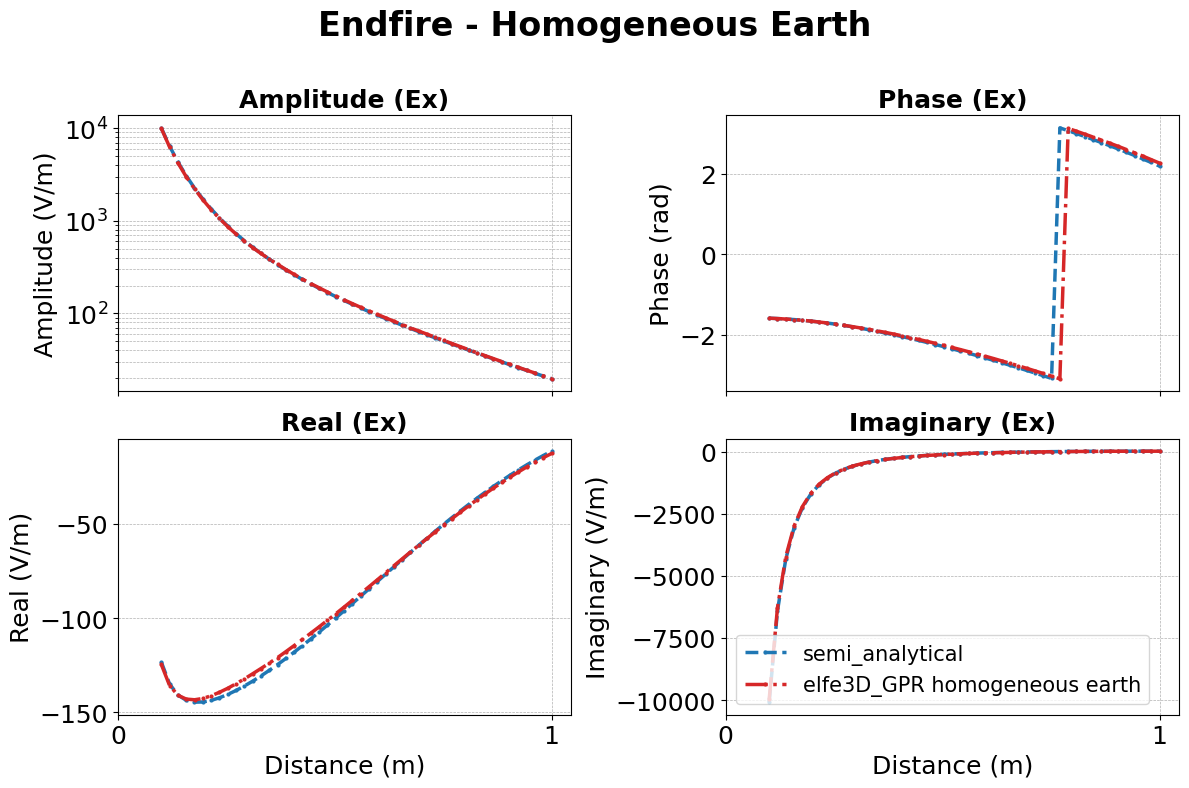

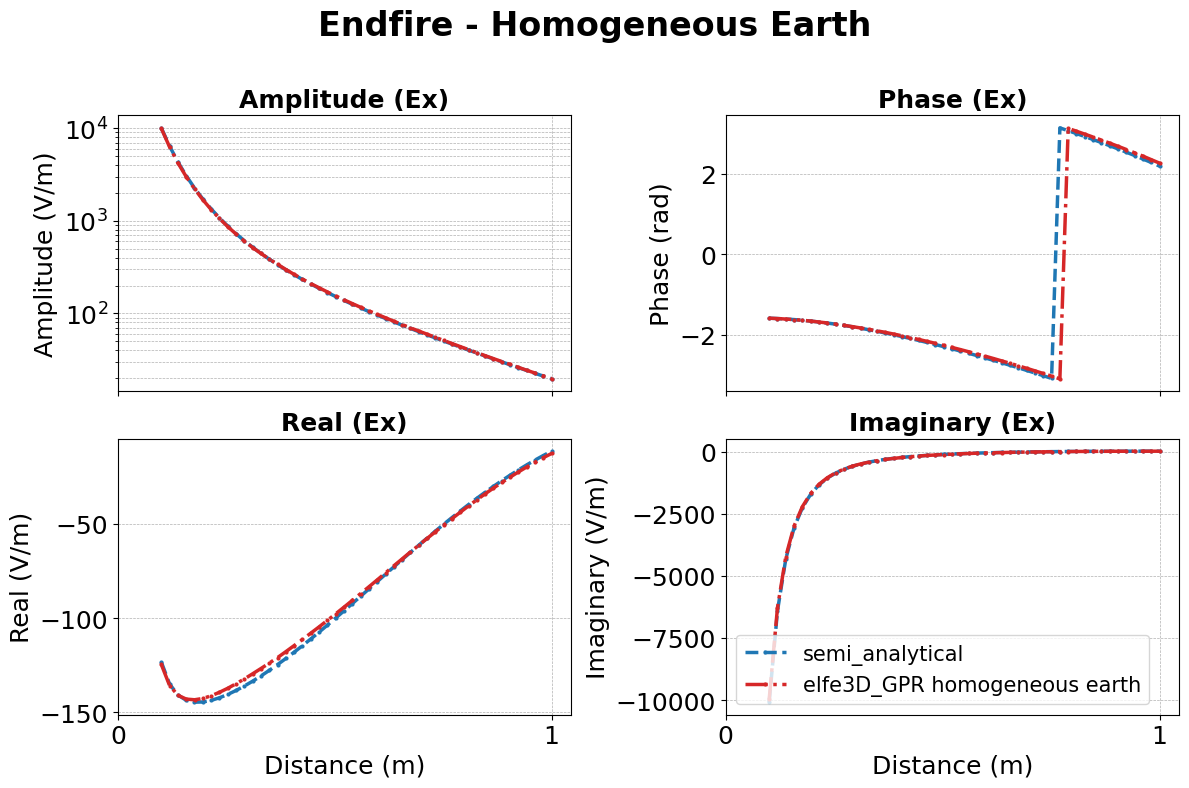

In [7]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Homogeneous Earth")

### 7.2. Error plot and quality check

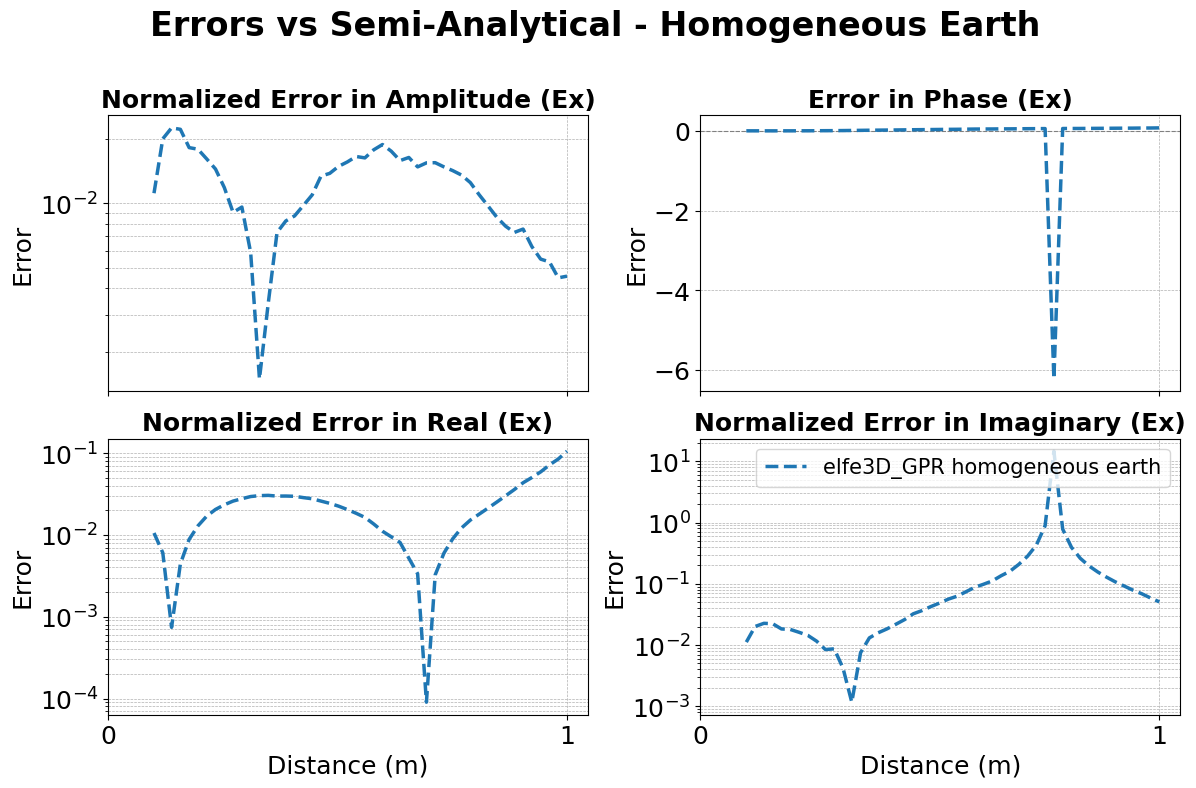

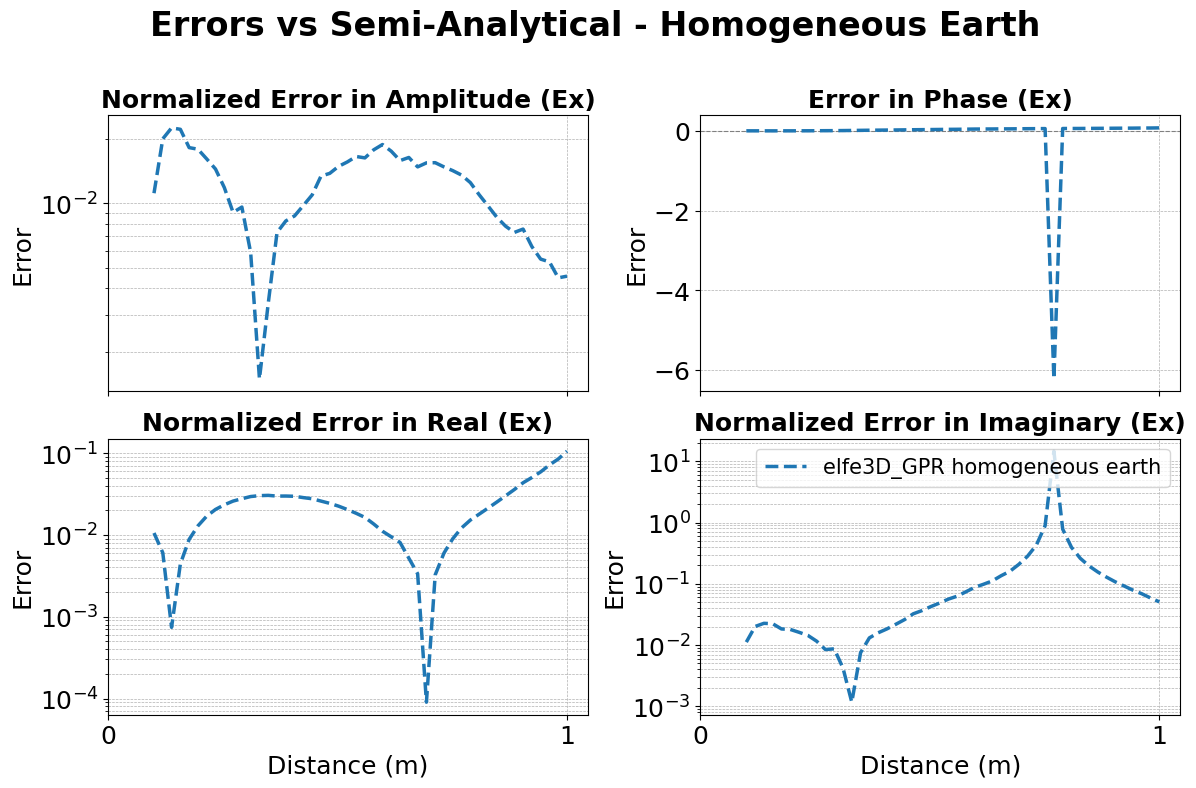

In [8]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Homogeneous Earth")

### 7.3. Combined field and error plot

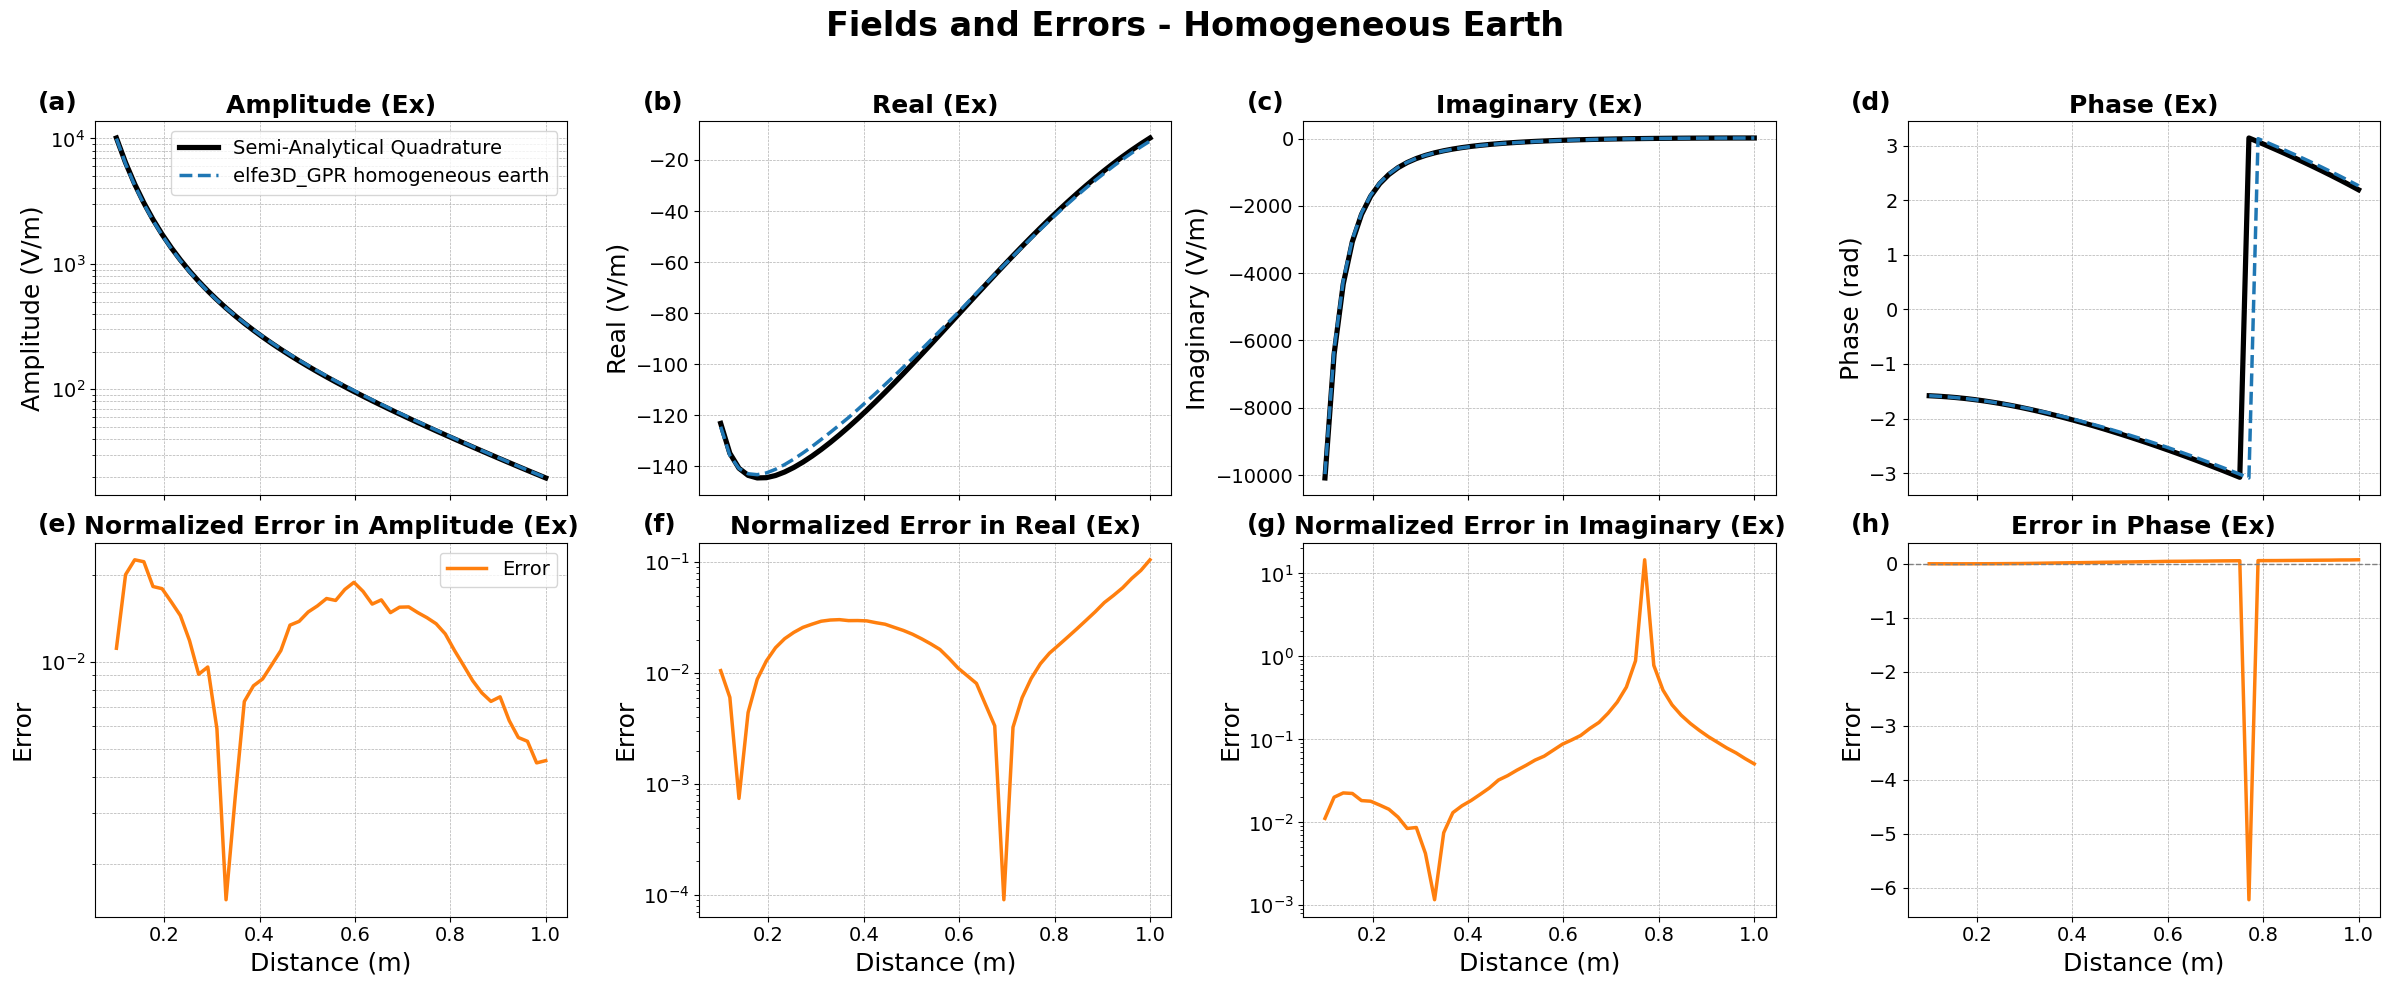

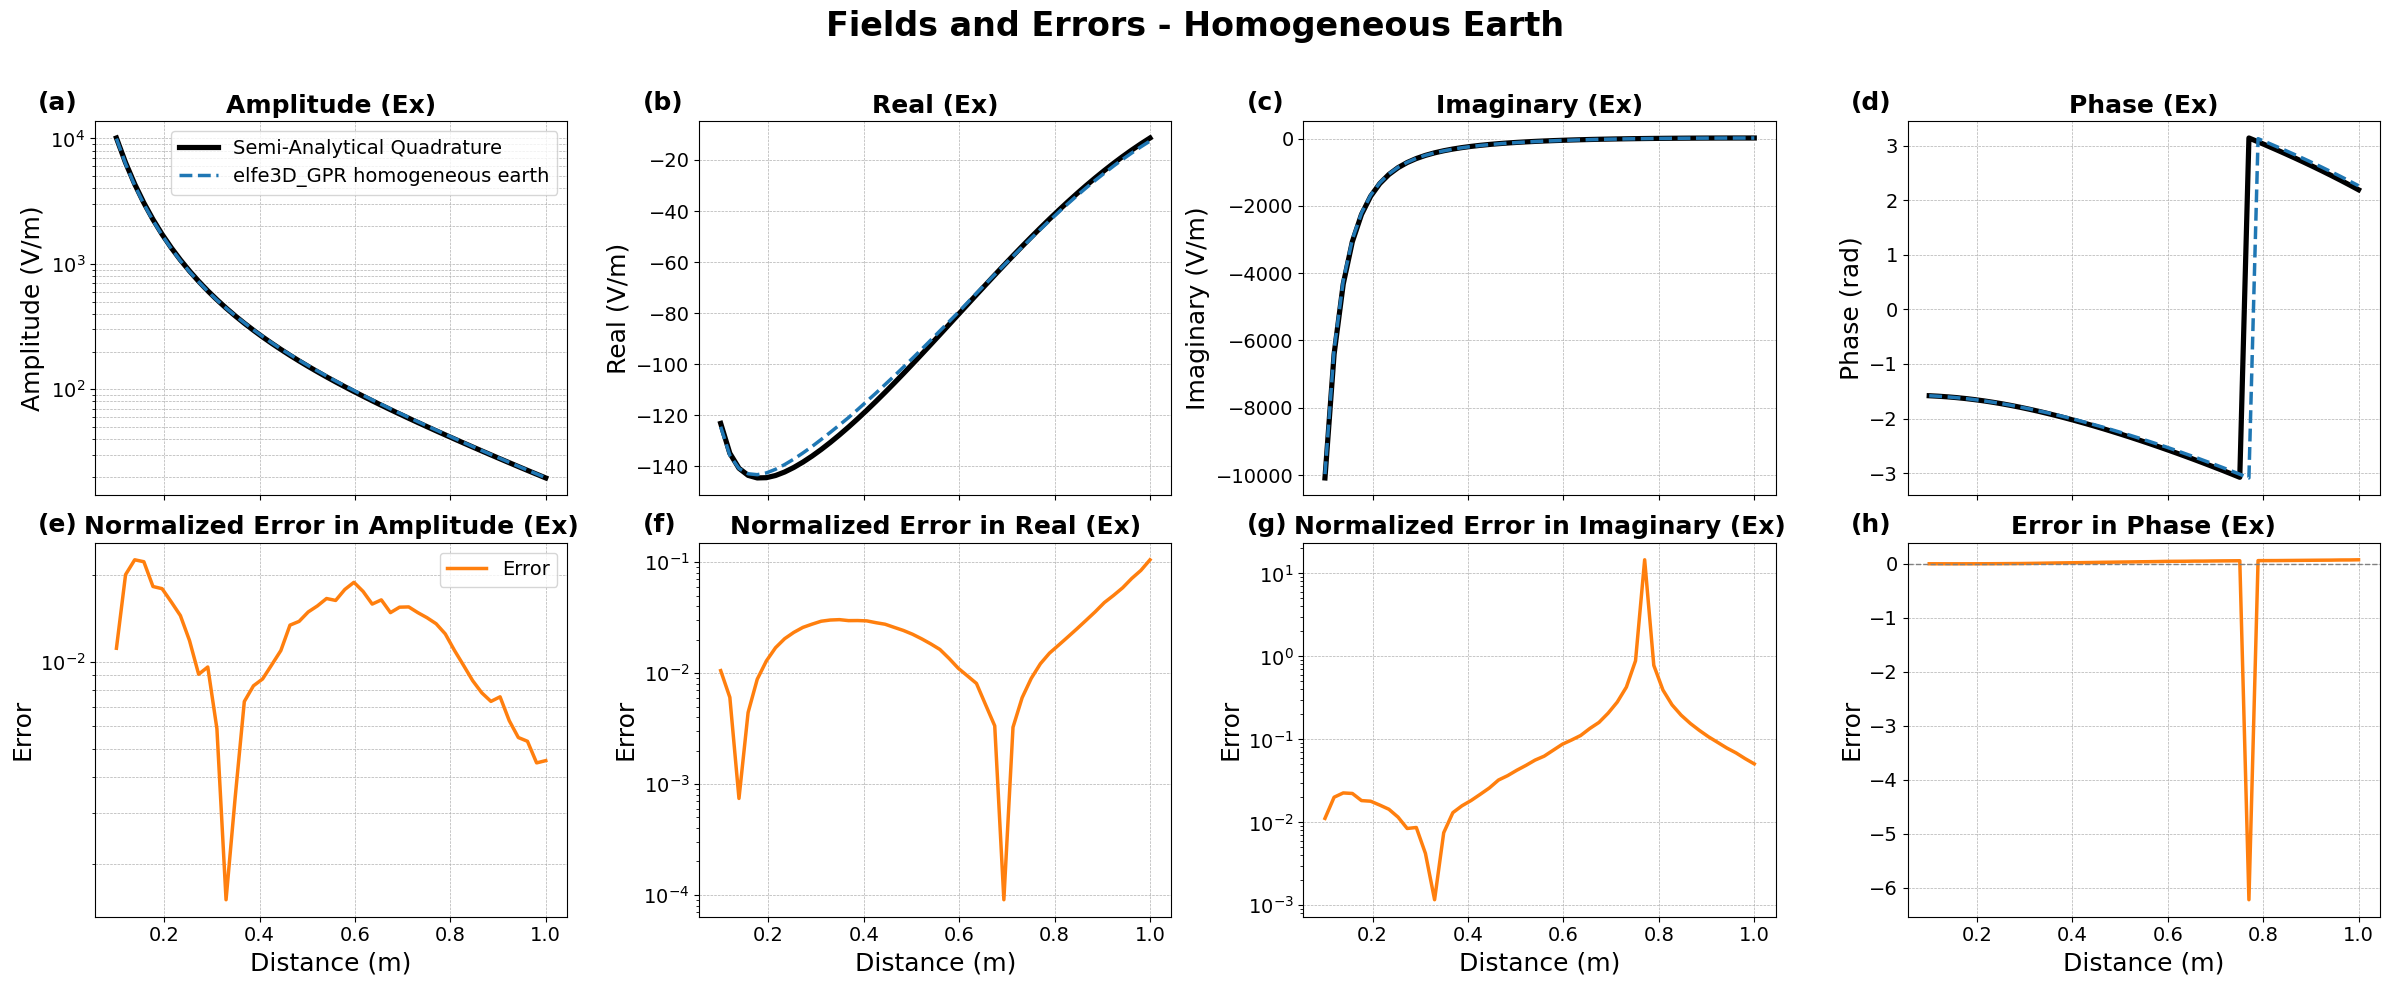

In [9]:
ReceiverLineCombined(ef, semi_analytical).plot(suptitle="Fields and Errors - Homogeneous Earth")

### 7.4. Error distribution histogram

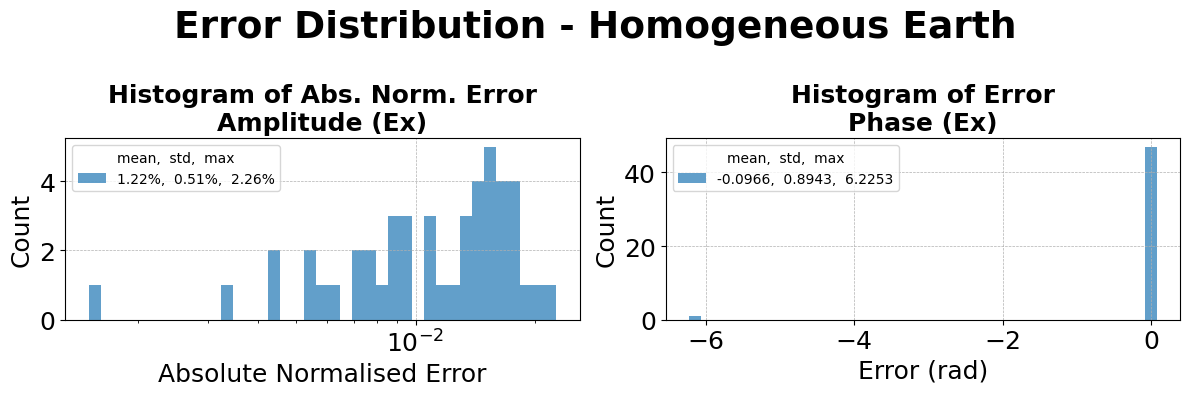

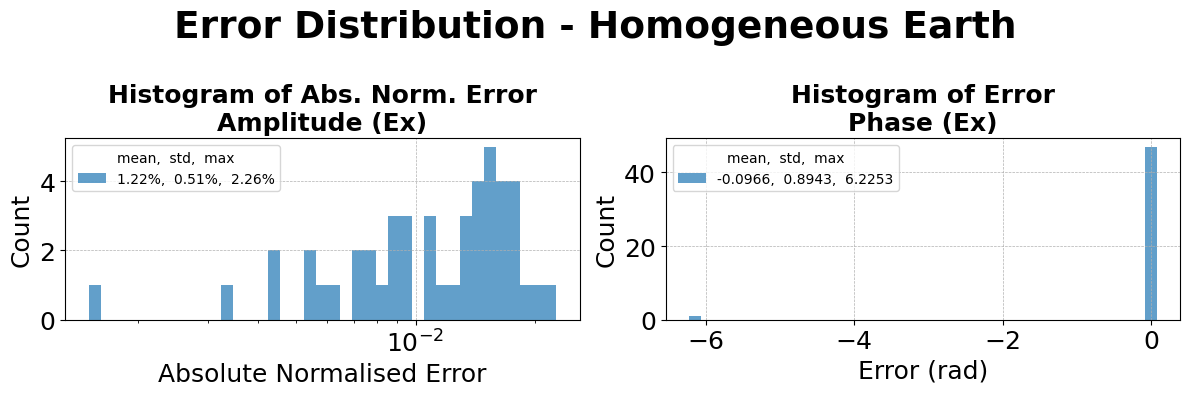

In [10]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle="Error Distribution - Homogeneous Earth")

## 8. Printed Error Summary

Using the data generated in the post-processing during plotting, and using the `field_error()` function, we now print some useful statistics of errors.

In [11]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
for qi, name in enumerate(qty_names):
    err = field_error(semi_analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')


  Amplitude   :  mean=1.221%  std=0.508%  max=2.261%
  Phase       :  mean=-0.097rad  std=0.894rad  max=6.225rad
  Real        :  mean=2.419%  std=2.069%  max=10.542%
  Imaginary   :  mean=41.673%  std=207.723%  max=1460.529%


## 9. Conclusions

This notebook started modelling a simple starting geophysical model of a homogeneous half-space to validate against the semi-analytical solution.

In the next notebook, we will add a higher dielectric permittivity geophysical layer and look at parametric simulations.